# Dependencies

In [1]:
import os
import glob

In [2]:
import json
import joblib
from joblib import Parallel, delayed, parallel_config
from typing import cast

In [3]:
import math
import numpy as np
import pandas as pd
import polars as pl

## Plotting

In [4]:
import matplotlib.pyplot as plt

## Pre-Processing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

## Variables

In [6]:
PATH_CACHE = "cache"

## Helper

In [7]:
def get_all_file_names(source_folder_name:str,file_format:str = ""):
    """List file names in source_folder_name that end with `.{file_format}`, sorted alphabetically.

    Note: if file_format is left empty, this returns an empty list (files are only ever
    appended when a format is given), so a format should always be supplied.
    """
    files = []
    for file in os.listdir(source_folder_name):
        if len(file_format)>0:
            if file.endswith(f".{file_format}"):
                files.append(file)
    return sorted(files)


In [8]:
def filter_file_names(list_file_names:list, filter_word:str):
    """Return only the file names that contain filter_word as a substring (e.g. a date like "2018-02-14")."""
    filtered_file_names = []
    for file_name in list_file_names:
        if filter_word in file_name:
            filtered_file_names.append(file_name)
    return filtered_file_names

In [9]:
def to_pandas_dataframe(data, template_column: list) -> pd.DataFrame:
    """Build a DataFrame from `data` and reindex its columns to match `template_column`."""
    df = pd.DataFrame(data)
    df = df.reindex(columns=template_column)
    return df

In [10]:
def get_split_parquet_files(source_folder_name: str, split_name: str) -> list[str]:
    """Return sorted paths to all Parquet files under `source_folder_name/split_name` (e.g. .../train)."""
    files = sorted(glob.glob(os.path.join(source_folder_name, split_name, "*.parquet")))
    if not files:
        raise FileNotFoundError(f"No Parquet files found in {os.path.join(source_folder_name, split_name)}")
    print(f"Found {len(files)} {split_name} files")
    return files

# Pre-Processing

## Change CSV to Parquet

In [11]:
CHUNK_SIZE = 100000
PATH_FOLDER_CSV = "cse-cic-ids2018"
PATH_FOLDER_RAW = "raw"
LABEL_COLUMN = "Label"
COLUMNS_TO_DROP = {
    "flow id", "src ip", "source ip", "src port", "source port",
    "dst ip", "destination ip", "timestamp",
}

In [12]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.str.strip().str.lower()
    return df

In [13]:
def drop_unwanted_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=COLUMNS_TO_DROP, errors="ignore")

In [14]:
def dataframe_to_parquet(chunk: pd.DataFrame, target_folder_name: str, file_name: str, template_columns: list[str] | None = None):
    chunk = normalize_columns(chunk)
    chunk = drop_unwanted_columns(chunk)

    if template_columns is not None:
        chunk = chunk.reindex(columns=template_columns)

    label = LABEL_COLUMN.lower()
    for col in chunk.columns:
        if col != label:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float64")

    chunk = chunk[chunk[label].str.lower() != label]
    chunk = chunk.dropna(subset=[label])
    output_file = os.path.join(target_folder_name, file_name)
    chunk.to_parquet(output_file, engine="pyarrow", compression="snappy", index=False)

In [15]:
def create_template_columns(files: list, source_folder_name: str):
    template_columns = []
    seen = set()
    for file_name in files:
        source_file = os.path.join(source_folder_name, file_name)
        cols = pd.read_csv(source_file, nrows=0).columns.str.strip().str.lower().tolist()
        for c in cols:
            if c not in seen and c not in COLUMNS_TO_DROP:
                seen.add(c)
                template_columns.append(c)
    return template_columns

In [16]:
def get_template_columns(source_folder_name, template_column_path: str = "dataframe-index.pkl"):
    csv_files = get_all_file_names(source_folder_name, "csv")
    template_columns = create_template_columns(csv_files,source_folder_name)
    joblib.dump(template_columns, template_column_path)

In [17]:
def _convert_single_csv_file(
    source_folder_name: str,
    target_folder_name: str,
    file_name: str,
    template_columns: list[str],
    chunk_size: int,
):
    source_file = os.path.join(source_folder_name, file_name)
    base_name = os.path.splitext(file_name)[0]

    for chunk_number, chunk in enumerate(pd.read_csv(source_file, chunksize=chunk_size, low_memory=False), start=1):
        dataframe_to_parquet(chunk, target_folder_name, f"{base_name}_{chunk_number:05d}.parquet", template_columns)

def convert_all_file_to_parquet(
    source_folder_name: str,
    target_folder_name: str,
    chunk_size: int = CHUNK_SIZE
):
    csv_files = get_all_file_names(source_folder_name, "csv")
    template_columns = create_template_columns(csv_files,source_folder_name)

    total = len(csv_files)
    os.makedirs(target_folder_name, exist_ok=True)

    with parallel_config(backend="loky", inner_max_num_threads=1):
        Parallel(n_jobs=-1, verbose=5)(
            delayed(_convert_single_csv_file)(source_folder_name, target_folder_name, file_name, template_columns, chunk_size)
            for file_name in csv_files
        )

    print(f"Finished processing {total} files.")

In [18]:
convert_all_file_to_parquet(PATH_FOLDER_CSV, PATH_FOLDER_RAW, CHUNK_SIZE)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:   17.5s remaining:  1.2min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   19.5s remaining:   19.5s
[Parallel(n_jobs=-1)]: Done   8 out of  10 | elapsed:   20.4s remaining:    5.0s


Finished processing 10 files.


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.5min finished


## Exploratory Data Analysis

## Change Infinite Values to NaN


Infinite values ($\infty$ and $-\infty$ / `np.inf` and `-np.inf`) are converted to `NaN` values to ensure that they can be handled consistently during the subsequent missing-value imputation process. This transformation allows both originally missing values and invalid infinite values to be processed using the same imputation method.

In [19]:
PATH_FOLDER_NO_INF = "data-no-inf"

In [20]:
def calculate_inf_values(
    source_folder_name: str
):
    parquet_files = get_all_file_names(source_folder_name,"parquet")
    total = len(parquet_files)
    count = 0
    for i, file_name in enumerate(parquet_files, start=1):
        print(f"Processing [{i}/{total}] {file_name}...", end="\r", flush=True)
        source_file = os.path.join(source_folder_name, file_name)
        df = pd.read_parquet(source_file)
        inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
        count += inf_count
    print("\n")
    print(f"Completed. Processed {total} files.")
    print(f"Found {count} inf values")

In [21]:
calculate_inf_values(PATH_FOLDER_RAW)

Processing [168/168] 2018-03-02-Friday_TrafficForML_CICFlowMeter_00011.parquet......

Completed. Processed 168 files.
Found 131799 inf values


In [22]:
def _change_inf_to_nan_single_file(source_folder_name: str, target_folder_name: str, file_name: str):
    source_file = os.path.join(source_folder_name, file_name)
    target_file = os.path.join(target_folder_name, file_name)

    df = pd.read_parquet(source_file)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.to_parquet(target_file, index=False)

def change_inf_to_nan(
    source_folder_name: str,
    target_folder_name: str
):
    os.makedirs(target_folder_name, exist_ok=True)

    parquet_files = get_all_file_names(source_folder_name,"parquet")
    total = len(parquet_files)

    with parallel_config(backend="loky", inner_max_num_threads=1):
        Parallel(n_jobs=-1, verbose=5)(
            delayed(_change_inf_to_nan_single_file)(source_folder_name, target_folder_name, file_name)
            for file_name in parquet_files
        )

    print(f"Completed. Processed {total} files.")

In [23]:
change_inf_to_nan(PATH_FOLDER_RAW, PATH_FOLDER_NO_INF)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    6.1s


Completed. Processed 168 files.


[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:    7.7s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:    7.8s finished


In [24]:
calculate_inf_values(PATH_FOLDER_NO_INF)

Processing [168/168] 2018-03-02-Friday_TrafficForML_CICFlowMeter_00011.parquet......

Completed. Processed 168 files.
Found 0 inf values


The dataset was cleaned by converting both positive infinite  and negative infinite values ($\infty$ and $-\infty$ / `np.inf` and `-np.inf`) to `NaN`. A total of **121,886 infinite values** were identified across **168 Parquet files** before the cleaning process. After the transformation, no infinite values remained in the dataset.

**Before cleaning:**

```text
Completed. Processed 168 files.
Found 131799 inf values
```

**After cleaning:**

```text
Completed. Processed 168 files.
Found 0.0 inf values
```

This ensures that all infinite values are handled as missing values and can subsequently be processed during the missing-value imputation stage.


## Train/Validation/Test Split

The CSE-CIC-IDS2018 dataset requires careful consideration when dividing the data into training, validation, and test sets. This is because the attack classes are not uniformly distributed across the dataset; instead, specific attack scenarios were conducted on particular dates. As a result, directly splitting the dataset based on individual days may cause some attack classes to be absent from one or more subsets.

The distribution of attack scenarios across the data collection dates is presented below:

| Date  | Attack(s)                           |
|-------|-------------------------------------|
| 14-02 | FTP-BruteForce, SSH-Bruteforce      |
| 15-02 | DoS-GoldenEye, DoS-Slowloris        |
| 16-02 | DoS-SlowHTTPTest, DoS-Hulk          |
| 20-02 | DDoS-LOIC-HTTP, DDoS-LOIC-UDP       |
| 21-02 | DDoS-LOIC-UDP, DDoS-HOIC            |
| 22-02 | Web Brute Force, XSS, SQL Injection |
| 23-02 | Web Brute Force, XSS, SQL Injection |
| 28-02 | Infiltration                        |
| 01-03 | Infiltration                        |
| 02-03 | Bot                                 |

This distribution indicates that several attack classes are associated with only one or a small number of collection dates. Therefore, assigning entire dates directly to the training, validation, or test set could result in certain attack classes being completely absent from the training data. Such a split would make the experiment evaluate unseen attack-class generalization rather than the intended robustness of the ML-IDS against input disturbances.

Therefore, the primary experiment uses a **stratified train/validation/test split based on the attack label**, ensuring that the attack classes are represented across the three subsets. The validation and test sets are kept separate from the training data to prevent information leakage during model development and final evaluation.

A separate day- or scenario-based split may subsequently be used as an additional experiment to evaluate the model's ability to generalize to traffic collected under different attack scenarios.


In [25]:
PATH_FOLDER_SPLIT_DATA = "data-split"
PATH_FOLDER_SPLIT_LABEL = "label-split"
bruteforce = "2018-02-14"
dos_golden = "2018-02-15"
dos_hulk = "2018-02-16"
ddos_http = "2018-02-20"
ddos_udp = "2018-02-21"
web_first = "2018-02-22"
web_second = "2018-02-23"
infiltration_first = "2018-02-28"
infiltration_second = "2018-03-01"
botnet = "2018-03-02"

In [26]:
def create_train_dev_test_folder(source_folder_name: str, features_folder_name: str, labels_folder_name: str, target_day):

    parquet_files = get_all_file_names(source_folder_name, "parquet")
    parquet_files = filter_file_names(parquet_files, target_day)

    if not parquet_files:
        print(f"No Parquet files found for {target_day}")
        raise ValueError(f"No Parquet files found for {target_day}")
    print(f"Found {len(parquet_files)} files for {target_day}")

    split_names = ("train", "dev", "test")
    feature_folders = {}
    label_folders = {}
    for split_name in split_names:
        feature_folder = os.path.join(features_folder_name, split_name)
        label_folder = os.path.join(labels_folder_name, split_name)
        os.makedirs(feature_folder, exist_ok=True)
        os.makedirs(label_folder, exist_ok=True)
        feature_folders[split_name] = feature_folder
        label_folders[split_name] = label_folder

    return parquet_files, feature_folders, label_folders

In [27]:
def _split_single_parquet_file(
    source_folder_name: str,
    file_name: str,
    feature_folders: dict[str, str],
    label_folders: dict[str, str],
    label_column: str,
    dev_size: float,
    test_size: float,
    random_state: int,
):
    source_file = os.path.join(source_folder_name, file_name)
    df = pd.read_parquet(source_file)

    train_df, temp_df = train_test_split(
        df,
        test_size=dev_size + test_size,
        random_state=random_state,
        stratify=df[label_column],
    )
    dev_df, test_df = train_test_split(
        temp_df,
        test_size=test_size / (dev_size + test_size),
        random_state=random_state,
        stratify=temp_df[label_column],
    )

    for split_name, split_df in (("train", train_df), ("dev", dev_df), ("test", test_df)):
        labels = split_df[[label_column]]
        features = split_df.drop(columns=[label_column])

        features.to_parquet(os.path.join(feature_folders[split_name], file_name), index=False)
        labels.to_parquet(os.path.join(label_folders[split_name], file_name), index=False)

def split_parquet_files(
    source_folder_name: str,
    parquet_files: list[str],
    feature_folders: dict[str, str],
    label_folders: dict[str, str],
    label_column: str,
    dev_size: float,
    test_size: float,
    random_state: int,
):
    total = len(parquet_files)

    with parallel_config(backend="loky", inner_max_num_threads=1):
        Parallel(n_jobs=-1, verbose=5)(
            delayed(_split_single_parquet_file)(
                source_folder_name, file_name, feature_folders, label_folders,
                label_column, dev_size, test_size, random_state,
            )
            for file_name in parquet_files
        )

    print(f"Completed splitting {total} files.")

In [28]:
def split_a_single_day(
    source_folder_name: str,
    features_folder_name: str,
    labels_folder_name: str,
    target_day: str,
    train_size: float = 0.60,
    dev_size: float = 0.20,
    test_size: float = 0.20,
    label_column: str = LABEL_COLUMN.lower(),
    random_state: int = 42,
):
    if min(train_size, dev_size, test_size) < 0.0:
        raise ValueError("train_size, dev_size, test_size must be non-negative")
    if not math.isclose(train_size + dev_size + test_size, 1.0, abs_tol=1e-9):
        raise ValueError("train_size + dev_size + test_size must equal 1.0")

    parquet_files, feature_folders, label_folders = create_train_dev_test_folder(
        source_folder_name, features_folder_name, labels_folder_name, target_day
    )

    split_parquet_files(
        source_folder_name,
        parquet_files,
        feature_folders,
        label_folders,
        label_column,
        dev_size,
        test_size,
        random_state,
    )

In [29]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, bruteforce)

Found 11 files for 2018-02-14


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  11 | elapsed:    1.6s remaining:    4.5s


Completed splitting 11 files.


[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    1.9s remaining:    1.5s
[Parallel(n_jobs=-1)]: Done   9 out of  11 | elapsed:    1.9s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    1.9s finished


In [30]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, dos_golden)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Found 11 files for 2018-02-15


[Parallel(n_jobs=-1)]: Done   3 out of  11 | elapsed:    2.1s remaining:    5.7s
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    2.2s remaining:    1.8s


Completed splitting 11 files.


[Parallel(n_jobs=-1)]: Done   9 out of  11 | elapsed:    2.3s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    2.4s finished


In [31]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, dos_hulk)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Found 11 files for 2018-02-16


[Parallel(n_jobs=-1)]: Done   3 out of  11 | elapsed:    0.6s remaining:    1.7s
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    0.7s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done   9 out of  11 | elapsed:    0.7s remaining:    0.1s


Completed splitting 11 files.


[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    1.4s finished


In [32]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, ddos_http)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Found 80 files for 2018-02-20


[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  50 out of  80 | elapsed:    4.2s remaining:    2.5s
[Parallel(n_jobs=-1)]: Done  67 out of  80 | elapsed:    4.8s remaining:    0.9s


Completed splitting 80 files.


[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:    5.2s finished


In [33]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, ddos_udp)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Found 11 files for 2018-02-21
Completed splitting 11 files.


[Parallel(n_jobs=-1)]: Done   3 out of  11 | elapsed:    0.5s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    0.6s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   9 out of  11 | elapsed:    0.6s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.6s finished


In [34]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, web_first)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Found 11 files for 2018-02-22
Completed splitting 11 files.


[Parallel(n_jobs=-1)]: Done   3 out of  11 | elapsed:    0.6s remaining:    1.9s
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    0.7s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   9 out of  11 | elapsed:    0.7s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.7s finished


In [35]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, web_second)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Found 11 files for 2018-02-23
Completed splitting 11 files.


[Parallel(n_jobs=-1)]: Done   3 out of  11 | elapsed:    0.7s remaining:    2.0s
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    0.7s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done   9 out of  11 | elapsed:    0.7s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.7s finished


In [36]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, infiltration_first)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Found 7 files for 2018-02-28
Completed splitting 7 files.


[Parallel(n_jobs=-1)]: Done   2 out of   7 | elapsed:    0.5s remaining:    1.4s
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.5s finished


In [37]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, infiltration_second)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Found 4 files for 2018-03-01
Completed splitting 4 files.


[Parallel(n_jobs=-1)]: Done   2 out of   4 | elapsed:    0.4s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   4 out of   4 | elapsed:    0.4s finished


In [38]:
split_a_single_day(PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_SPLIT_LABEL, botnet)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Found 11 files for 2018-03-02
Completed splitting 11 files.


[Parallel(n_jobs=-1)]: Done   3 out of  11 | elapsed:    0.5s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    0.6s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   9 out of  11 | elapsed:    0.6s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.6s finished


Files are successfully split.

## Imputation

Missing values are filled using **per-column medians computed from the training split only**, then applied to train/dev/test. Using the median (rather than the mean) avoids distortion from the heavy outliers typical of network flow features (e.g. flow duration, byte counts). Fitting the medians on the training split only and reusing them for dev/test prevents information leakage from the validation/test sets into preprocessing.

### Create Imputation

imputation for NaN

In [39]:
PATH_IMPUTER = "cache/median-imputer.json"

In [40]:
def load_combined_lazyframe(train_files: list[str]) -> pl.LazyFrame:
    """Lazily load and concatenate all train Parquet files into a single LazyFrame."""
    lazy_frames = []
    total = len(train_files)
    for i,file in enumerate(train_files,start=1):
        print(f"Processing [{i}/{total}] {file}...", end="\r", flush=True)
        lazy_frames.append(pl.scan_parquet(file))
    return pl.concat(lazy_frames, how="diagonal_relaxed")

In [41]:
def get_numeric_columns(combined: pl.LazyFrame) -> list[str]:
    schema = combined.collect_schema()
    numeric_cols = [
        column for column, dtype in zip(schema.names(), schema.dtypes())
        if dtype.is_numeric()
    ]
    print(f"Found {len(numeric_cols)} numeric columns")
    return numeric_cols

In [42]:
def compute_medians(combined: pl.LazyFrame, numeric_cols: list[str]) -> pl.DataFrame:
    median_exprs = []
    total = len(numeric_cols)
    for i,column in enumerate(numeric_cols,start=1):
        print(f"Processing [{i}/{total}] {column}...", end="\r", flush=True)
        expr = pl.col(column).median().alias(column)
        median_exprs.append(expr)

    medians = combined.select(median_exprs).collect()
    return medians

In [43]:
def build_median_dict(medians: pl.DataFrame, numeric_cols: list[str]) -> dict[str, float]:
    median_dict = {}
    null_columns = []

    for c in numeric_cols:
        val = medians[c][0]
        if val is None:
            null_columns.append(c)
            median_dict[c] = 0.0
        else:
            median_dict[c] = float(val)

    if null_columns:
        print(f"Warning: {len(null_columns)} columns had no non-null values, defaulted to 0.0: {null_columns}")

    return median_dict

In [44]:
def save_median_dict(median_dict: dict[str, float], output_file: str):
    with open(output_file, "w") as file:
        json.dump(median_dict, file, indent=4)
    print(f"Saved medians to: {output_file}")

In [45]:
def get_median_imputation(source_folder_name: str, output_file: str) -> dict[str, float]:
    train_files = get_split_parquet_files(source_folder_name, "train")
    combined = load_combined_lazyframe(train_files)
    numeric_cols = get_numeric_columns(combined)
    medians = compute_medians(combined, numeric_cols)
    median_dict = build_median_dict(medians, numeric_cols)
    save_median_dict(median_dict, output_file)
    return median_dict

In [46]:
median = get_median_imputation(PATH_FOLDER_SPLIT_DATA, PATH_IMPUTER)
print(json.dumps(median, indent=4))

Found 168 train files
Found 78 numeric columnsa-split\train\2018-03-02-Friday_TrafficForML_CICFlowMeter_00011.parquet......
Saved medians to: cache/median-imputer.json
{
    "dst port": 80.0,
    "protocol": 6.0,
    "flow duration": 20967.0,
    "tot fwd pkts": 2.0,
    "tot bwd pkts": 1.0,
    "totlen fwd pkts": 43.0,
    "totlen bwd pkts": 101.0,
    "fwd pkt len max": 40.0,
    "fwd pkt len min": 0.0,
    "fwd pkt len mean": 36.0,
    "fwd pkt len std": 0.0,
    "bwd pkt len max": 95.0,
    "bwd pkt len min": 0.0,
    "bwd pkt len mean": 66.0,
    "bwd pkt len std": 0.0,
    "flow byts/s": 786.0036016321501,
    "flow pkts/s": 136.2026696,
    "flow iat mean": 11706.0,
    "flow iat std": 60.85789458125,
    "flow iat max": 18700.0,
    "flow iat min": 53.0,
    "fwd iat tot": 5147.0,
    "fwd iat mean": 3605.0,
    "fwd iat std": 0.0,
    "fwd iat max": 5037.0,
    "fwd iat min": 37.0,
    "bwd iat tot": 0.0,
    "bwd iat mean": 0.0,
    "bwd iat std": 0.0,
    "bwd iat max": 0.0,

### Impute Training Data

In [47]:
PATH_FOLDER_IMPUTED = "data-imputed"

In [48]:
def impute_dataframe(df:pd.DataFrame, medians):
    for column, median in medians.items():
        if column in df.columns:
            df[column] = df[column].fillna(median)
    return df

In [49]:
def _impute_single_file(source_file: str, output_split_folder: str, medians: dict[str, float]):
    df = pd.read_parquet(source_file)
    df = impute_dataframe(df, medians)
    output_file = os.path.join(output_split_folder, os.path.basename(source_file))
    df.to_parquet(
        output_file,
        engine="pyarrow",
        compression="snappy",
        index=False
    )

def impute_all_split_files(source_folder_name: str, output_folder_name: str, medians_path: str):
    with open(medians_path, "r") as f:
        medians = json.load(f)

    for split_name in ("train", "dev", "test"):
        files = get_split_parquet_files(source_folder_name, split_name)
        total = len(files)
        output_split_folder = os.path.join(output_folder_name, split_name)
        os.makedirs(output_split_folder, exist_ok=True)

        with parallel_config(backend="loky", inner_max_num_threads=1):
            Parallel(n_jobs=-1, verbose=5)(
                delayed(_impute_single_file)(file, output_split_folder, medians)
                for file in files
            )

        print(f"Finished imputing {total} {split_name} files.")

In [50]:
impute_all_split_files(PATH_FOLDER_SPLIT_DATA, PATH_FOLDER_IMPUTED, PATH_IMPUTER)

Found 168 train files


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:    4.0s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:    4.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Finished imputing 168 train files.
Found 168 dev files


[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:    1.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:    1.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Finished imputing 168 dev files.
Found 168 test files


[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.2s


Finished imputing 168 test files.


[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:    1.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:    1.5s finished


## Normalized or Feature Scaling

Features are standardized (zero mean, unit variance) using `StandardScaler`. As with imputation, the scaler is fit with `partial_fit` on the **train split only** (processed file-by-file to avoid loading the full ~16M-row dataset into memory at once), then reused to transform train/dev/test. This keeps dev/test statistically unseen during fitting and puts every feature on a comparable scale, which PCA and distance/gradient-based models both depend on.

### Create Scaler

In [51]:
PATH_SCALER = "cache/standard-scaler.pkl"

In [52]:
def fit_scaler_on_files(scaler: StandardScaler, file_paths: list[str]) -> StandardScaler:
    total = len(file_paths)
    for i, file_path in enumerate(file_paths, start=1):
        print(f"Processing [{i}/{total}] {file_path}...", end="\r", flush=True)
        df = pd.read_parquet(file_path)

        if df.empty:
            print(f"Empty file found: {file_path}")
            continue

        scaler.partial_fit(df)
    return scaler

In [53]:
def create_standard_scaler(source_folder_name: str, split_name: str = "train") -> StandardScaler:
    file_paths = get_split_parquet_files(source_folder_name, split_name)
    scaler = StandardScaler()
    scaler = fit_scaler_on_files(scaler, file_paths)

    if not hasattr(scaler, "mean_"):
        raise ValueError("The scaler could not be fitted because all files were empty.")

    print(" " * 100, end="\r")
    print(f"Successfully fitted scaler using {len(file_paths)} Parquet file(s) from '{split_name}'.")

    return scaler

In [54]:
def dump_standard_scaler(scaler: StandardScaler,output_path:str):
    joblib.dump(scaler,output_path)

In [55]:
def get_standard_scaler(source_folder_name:str,output_path:str):
    scaler = create_standard_scaler(source_folder_name)
    dump_standard_scaler(scaler,output_path)

In [56]:
get_standard_scaler(PATH_FOLDER_IMPUTED, PATH_SCALER)

Found 168 train files
Successfully fitted scaler using 168 Parquet file(s) from 'train'.                                  ...


### Scale Training Data

In [57]:
PATH_FOLDER_SCALED = "data-scaled"

In [58]:
def load_standard_scaler(path:str)->StandardScaler:
    return joblib.load(path)

In [59]:
def _scale_single_file(file_path: str, scaler: StandardScaler, output_split_folder: str):
    df = pd.read_parquet(file_path)
    columns = df.columns.tolist()

    data = scaler.transform(df)
    scaled_df = pd.DataFrame(data, columns=columns)

    scaled_df.to_parquet(
        os.path.join(output_split_folder, os.path.basename(file_path)),
        engine="pyarrow",
        compression="snappy",
        index=False
    )

def scale_split_files(source_folder_name: str, scaler_path: str, output_folder_name: str):
    scaler = load_standard_scaler(scaler_path)

    for split_name in ("train", "dev", "test"):
        file_paths = get_split_parquet_files(source_folder_name, split_name)
        output_split_folder = os.path.join(output_folder_name, split_name)
        os.makedirs(output_split_folder, exist_ok=True)
        total = len(file_paths)

        with parallel_config(backend="loky", inner_max_num_threads=1):
            Parallel(n_jobs=-1, verbose=5)(
                delayed(_scale_single_file)(file_path, scaler, output_split_folder)
                for file_path in file_paths
            )

        print(f"Finished scaling {total} {split_name} files.")

In [60]:
scale_split_files(PATH_FOLDER_IMPUTED, PATH_SCALER, PATH_FOLDER_SCALED)

Found 168 train files


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:    4.9s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:    5.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Finished scaling 168 train files.
Found 168 dev files


[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:    1.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:    1.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Finished scaling 168 dev files.
Found 168 test files


[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.2s


Finished scaling 168 test files.


[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:    1.5s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:    1.6s finished


# Principal Component Analysis (PCA)

`IncrementalPCA` is used instead of standard `PCA` because it supports `partial_fit` on mini-batches, so the scaled dataset never needs to be fully loaded into memory. Transformers are fit for a range of component counts (5-40) so the explained-variance-vs-components trade-off can be inspected before committing to a final value.

### Creating Incremental Principal Component Analysis

In [61]:
PATH_FOLDER_IPCA_TRANSFORMER = os.path.join(PATH_CACHE,"pca")
PATH_IPCA = "ipca-transformer.pkl"
LIST_PC_COMPONENTS = [5,10,15,20,25,30,35,40]

In [62]:
def fit_ipca_on_files(ipca: IncrementalPCA, file_paths: list[str]) -> IncrementalPCA:
    total = len(file_paths)
    for i, file_path in enumerate(file_paths, start=1):
        print(f"Processing [{i}/{total}] {file_path}...", end="\r", flush=True)
        df = pd.read_parquet(file_path)

        if df.empty:
            print(f"Empty file found: {file_path}")
            continue

        ipca.partial_fit(df)
    print(" " * 100, end="\r")
    return ipca

In [63]:
def create_ipca(n_components,source_folder_name: str, split_name: str = "train") -> IncrementalPCA:
    print(f"Creating IPCA transfromer with {n_components} pc")
    file_paths = get_split_parquet_files(source_folder_name, split_name)
    ipca = IncrementalPCA(n_components=n_components)
    ipca = fit_ipca_on_files(ipca, file_paths)
    print(f"Successfully fitted ipca with {n_components} pc from '{split_name}'.")

    return ipca

In [64]:
def get_ipca_transformer_path(pc:int, ipca_path:str)->str:
    return f"{pc}-pc-{ipca_path}"

In [65]:
def dump_ipca(ipca: IncrementalPCA, transformer_folder:str = PATH_FOLDER_IPCA_TRANSFORMER,ipca_path:str = PATH_IPCA):
    filename = get_ipca_transformer_path(ipca.n_components_,ipca_path)
    joblib.dump(ipca,os.path.join(transformer_folder, filename))

In [66]:
def get_ipca(list_pc_components: list, source_folder_name: str, output_path: str):
    os.makedirs(PATH_FOLDER_IPCA_TRANSFORMER, exist_ok=True)
    for pc in list_pc_components:
        ipca = create_ipca(pc, source_folder_name)
        dump_ipca(ipca, PATH_FOLDER_IPCA_TRANSFORMER, output_path)

In [67]:
get_ipca(LIST_PC_COMPONENTS,PATH_FOLDER_SCALED, PATH_IPCA)

Creating IPCA transfromer with 5 pc
Found 168 train files
Successfully fitted ipca with 5 pc from 'train'.                                                    ..
Creating IPCA transfromer with 10 pc
Found 168 train files
Successfully fitted ipca with 10 pc from 'train'.                                                   ..
Creating IPCA transfromer with 15 pc
Found 168 train files
Successfully fitted ipca with 15 pc from 'train'.                                                   ..
Creating IPCA transfromer with 20 pc
Found 168 train files
Successfully fitted ipca with 20 pc from 'train'.                                                   ..
Creating IPCA transfromer with 25 pc
Found 168 train files
Successfully fitted ipca with 25 pc from 'train'.                                                   ..
Creating IPCA transfromer with 30 pc
Found 168 train files
Successfully fitted ipca with 30 pc from 'train'.                                                   ..
Creating IPCA transfromer wit

### Evaluate Incremental Principal Component Analysis

In [68]:
def load_ipca(pc:int,transformer_folder:str = PATH_FOLDER_IPCA_TRANSFORMER,ipca_path:str = PATH_IPCA) -> IncrementalPCA:
    filename = get_ipca_transformer_path(pc,ipca_path)
    return joblib.load(os.path.join(transformer_folder, filename))

In [69]:
def evaluate_ipca_variance(list_pc_components: list) -> pd.DataFrame:
    rows = []
    for pc in list_pc_components:
        ipca = load_ipca(pc)

        cum_var = np.cumsum(ipca.explained_variance_ratio_)
        rows.append({
            "n_components": pc,
            "total_explained_variance": cum_var[-1],
            "explained_variance_ratio": ipca.explained_variance_ratio_,
        })

    return pd.DataFrame(rows)

In [70]:
def plot_ipca_variance(evaluation_results: pd.DataFrame):
    plt.figure(figsize=(8, 5))

    x = evaluation_results["n_components"]
    y = evaluation_results["total_explained_variance"]
    plt.plot(x, y, marker="o", color="black")
    for xi, yi in zip(x, y):
        plt.annotate(f"{yi:.3f}", (xi, yi), xytext=(0, 8), textcoords="offset points", ha="center")

    plt.axhline(0.95, color="red", linestyle="--", label="95% threshold")
    plt.xlabel("Principal Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("IPCA: Variance Retained vs. Principal Components")
    plt.legend()
    plt.grid(True)

    plt.show()

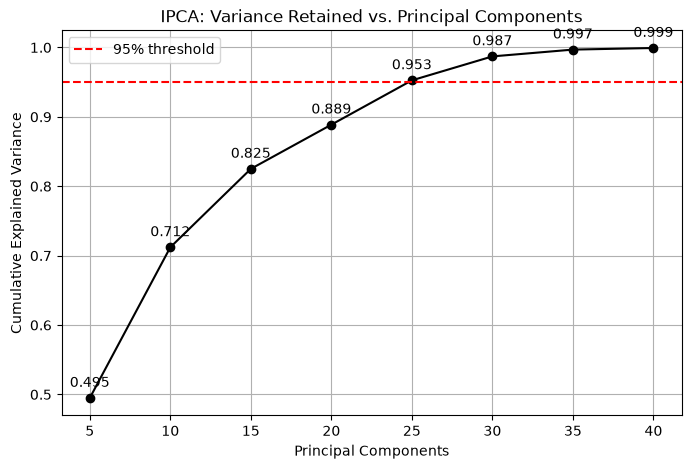

In [71]:
ipca_variance_results = evaluate_ipca_variance(LIST_PC_COMPONENTS)
plot_ipca_variance(ipca_variance_results)

### Implement Incremental Principal Component Analysis

`IPCA_PC_USED = 25` was chosen from the variance plot above as the smallest evaluated component count that clears the 95% cumulative explained-variance threshold.

In [72]:
PATH_FOLDER_IPCA = "data-ipca"
IPCA_PC_USED = 25

In [73]:
def _ipca_transform_single_file(file_path: str, ipca: IncrementalPCA, output_split_folder: str):
    df = pd.read_parquet(file_path)

    data = ipca.transform(df)
    pc_columns = [f"pc{i+1}" for i in range(data.shape[1])]
    scaled_df = pd.DataFrame(data, columns=pc_columns)

    scaled_df.to_parquet(
        os.path.join(output_split_folder, os.path.basename(file_path)),
        engine="pyarrow",
        compression="snappy",
        index=False
    )

def ipca_split_files(source_folder_name: str, ipca_path: str, output_folder_name: str):
    ipca = load_ipca(IPCA_PC_USED)

    for split_name in ("train", "dev", "test"):
        file_paths = get_split_parquet_files(source_folder_name, split_name)
        output_split_folder = os.path.join(output_folder_name, split_name)
        os.makedirs(output_split_folder, exist_ok=True)
        total = len(file_paths)

        with parallel_config(backend="loky", inner_max_num_threads=1):
            Parallel(n_jobs=-1, verbose=5)(
                delayed(_ipca_transform_single_file)(file_path, ipca, output_split_folder)
                for file_path in file_paths
            )

        print(f"Finished scaling {total} {split_name} files.")

In [74]:
ipca_split_files(PATH_FOLDER_SCALED, PATH_IPCA, PATH_FOLDER_IPCA)

Found 168 train files


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:   10.5s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:   10.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Finished scaling 168 train files.
Found 168 dev files


[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:    1.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:    1.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Finished scaling 168 dev files.
Found 168 test files


[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.2s


Finished scaling 168 test files.


[Parallel(n_jobs=-1)]: Done 121 out of 168 | elapsed:    1.2s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done 155 out of 168 | elapsed:    1.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed:    1.4s finished


## Synthetic Minor Oversampling Technique

CSE-CIC-IDS2018 is heavily imbalanced (Benign traffic dominates; some attack classes are a small fraction of a percent). SMOTE is applied to the **training split only** (never dev/test, so evaluation still reflects real-world class balance) to synthesize minority-class samples and reduce the model's bias toward the majority class.

SMOTE resamples the **PCA-reduced train features** (`PATH_FOLDER_IPCA`, paired with the original `PATH_FOLDER_SPLIT_LABEL` labels), since that's the final feature representation a downstream model would train on. Loading and saving both go through polars (`load_train_features_and_labels`, `save_smote_train_data`); imbalanced-learn itself only accepts numpy arrays, so the conversion happens right at the `SMOTE` calls and the result is wrapped back into a `pl.DataFrame`/`pl.Series`.

Because some attack classes (e.g. SQL Injection) have very few samples in this dataset, `fit_smote` clamps `k_neighbors` down to what the smallest class can support instead of letting `fit_resample` raise on the default `k_neighbors=5`. Fitting is kept separate from resampling: `fit_smote` fits and `dump_smote` persists the fitted transformer via joblib right away, and `resample_with_smote` performs the actual oversampling afterwards.

In [86]:
PATH_FOLDER_SMOTE = "data-smote"
PATH_FOLDER_SMOTE_TRANSFORMER = os.path.join(PATH_CACHE, "smote")
PATH_SMOTE = "smote-transformer.pkl"

In [82]:
def load_train_features_and_labels(features_folder_name: str, labels_folder_name: str, split_name: str = "train") -> tuple[pl.DataFrame, pl.Series]:
    feature_files = get_split_parquet_files(features_folder_name, split_name)
    label_files = get_split_parquet_files(labels_folder_name, split_name)

    print(f"Loading {len(feature_files)} '{split_name}' feature file(s)...", end="", flush=True)
    features_df = pl.concat([pl.scan_parquet(f) for f in feature_files]).collect()
    labels_df = pl.concat([pl.scan_parquet(f) for f in label_files]).select(LABEL_COLUMN.lower()).collect()

    print(f"Loaded {features_df.height} rows for '{split_name}'.")
    return features_df, labels_df.to_series()

In [83]:
def get_class_count(labels: pl.Series) -> dict:
    counts = labels.value_counts()
    return dict(zip(counts[labels.name].to_list(), counts["count"].to_list()))

In [84]:
def fit_smote(features: pl.DataFrame, labels: pl.Series, random_state: int = 42) -> SMOTE:
    class_counts = get_class_count(labels)
    print(f"Before SMOTE: {class_counts}")
    smallest_class_count = min(class_counts.values())
    k_neighbors = max(1, min(5, smallest_class_count - 1))
    if k_neighbors < 5:
        print(f"Warning: smallest class has {smallest_class_count} samples; reducing k_neighbors to {k_neighbors}")

    smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
    with parallel_config(n_jobs=-1):
        smote.fit(features.to_numpy(), labels.to_numpy())
    return smote

In [87]:
def dump_smote(smote: SMOTE, transformer_folder: str = PATH_FOLDER_SMOTE_TRANSFORMER, smote_path: str = PATH_SMOTE):
    os.makedirs(transformer_folder, exist_ok=True)
    output_path = os.path.join(transformer_folder, smote_path)
    joblib.dump(smote, output_path)
    print(f"Saved fitted SMOTE transformer to: {output_path}")

In [88]:
def resample_with_smote(smote: SMOTE, features: pl.DataFrame, labels: pl.Series) -> tuple[pl.DataFrame, pl.Series]:
    with parallel_config(n_jobs=-1):
        features_resampled, labels_resampled = smote.fit_resample(features.to_numpy(), labels.to_numpy())

    features_df = pl.DataFrame(features_resampled, schema=features.columns)
    labels_series = pl.Series(labels.name, labels_resampled)
    print(f"After SMOTE: {get_class_count(labels_series)}")
    return features_df, labels_series

In [89]:
def save_smote_train_data(features: pl.DataFrame, labels: pl.Series, output_folder_name: str, label_column: str = LABEL_COLUMN.lower()):
    os.makedirs(output_folder_name, exist_ok=True)
    df = features.with_columns(labels.alias(label_column))
    output_file = os.path.join(output_folder_name, "train_smote.parquet")
    df.write_parquet(output_file, compression="snappy")
    print(f"Saved SMOTE-resampled train data to: {output_file}")

In [90]:
def get_smote_train_data(features_folder_name: str, labels_folder_name: str, output_folder_name: str):
    features, labels = load_train_features_and_labels(features_folder_name, labels_folder_name)
    smote = fit_smote(features, labels)
    dump_smote(smote)
    features_resampled, labels_resampled = resample_with_smote(smote, features, labels)
    save_smote_train_data(features_resampled, labels_resampled, output_folder_name)

In [ ]:
get_smote_train_data(PATH_FOLDER_IPCA, PATH_FOLDER_SPLIT_LABEL, PATH_FOLDER_SMOTE)

Found 168 train files
Found 168 train files
Loading 168 'train' feature file(s)...Loaded 9739760 rows for 'train'.
Before SMOTE: {'DDOS attack-LOIC-UDP': 1038, 'Benign': 8090820, 'Bot': 171714, 'DDOS attack-HOIC': 411607, 'Brute Force -XSS': 138, 'FTP-BruteForce': 116016, 'DDoS attacks-LOIC-HTTP': 345715, 'Brute Force -Web': 367, 'DoS attacks-Hulk': 277146, 'DoS attacks-SlowHTTPTest': 83934, 'DoS attacks-GoldenEye': 24905, 'SQL Injection': 52, 'DoS attacks-Slowloris': 6594, 'Infilteration': 97160, 'SSH-Bruteforce': 112554}
Saved fitted SMOTE transformer to: cache\smote\smote-transformer.pkl


MemoryError: Unable to allocate 1.48 GiB for an array with shape (7919106, 25) and data type float64

: 

# Train Model